# K-Nearest Neighbors (KNN) Model

This notebook develops and evaluates a K-Nearest Neighbors (KNN) classification model for predicting Heart Disease Status.

## 1. Data Preparation

This section loads the heart disease dataset and prepares the data for the KNN model. Unnecessary attributes are removed and missing values are handled before model development.

In [3]:
from google.colab import files

uploaded = files.upload()


Saving heart_disease (1).csv to heart_disease (1).csv


In [4]:
import os

print(os.listdir())

['.config', 'heart_disease (1).csv', 'sample_data']


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("heart_disease (1).csv")

df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


### 1.1 Dataset Dimensions

The dimensions of the dataset are examined to determine the number of observations and attributes available for model development.

In [7]:
print("Dataset shape:", df.shape)

Dataset shape: (10000, 21)


### 1.2 Data Types and Missing Values

The data types of each attribute and the number of missing values are examined to identify variables that require preprocessing before applying the KNN algorithm.

In [8]:
# Display data types of all attributes
print(df.dtypes)

Age                     float64
Gender                   object
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits          object
Smoking                  object
Family Heart Disease     object
Diabetes                 object
BMI                     float64
High Blood Pressure      object
Low HDL Cholesterol      object
High LDL Cholesterol     object
Alcohol Consumption      object
Stress Level             object
Sleep Hours             float64
Sugar Consumption        object
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status     object
dtype: object


In [9]:
# Check the number of missing values in each attribute
print(df.isnull().sum())

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64


### 1.3 Handling Missing Values

Missing values are identified across the dataset. The `Alcohol Consumption` attribute contains a relatively large number of missing values and is therefore removed from the dataset. The remaining observations with missing values are then removed to prepare a complete dataset for KNN modelling.

In [10]:
# Remove Alcohol Consumption because of its large number of missing values
df = df.drop(columns=["Alcohol Consumption"])

# Remove remaining rows with missing values
df = df.dropna()

print("Dataset shape after handling missing values:", df.shape)

Dataset shape after handling missing values: (9532, 20)


## 2. Feature and Target Preparation

The target variable is separated from the predictor variables before applying categorical encoding and feature scaling for KNN classification.

In [11]:
# Define the target variable
target_column = "Heart Disease Status"

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9532, 19)
y shape: (9532,)


### 2.1 Categorical Feature Encoding

Categorical variables are converted into numerical representations using one-hot encoding so that they can be processed by the KNN algorithm.

In [12]:
# Identify categorical columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Categorical columns:")
print(list(categorical_columns))

Categorical columns:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Stress Level', 'Sugar Consumption']


### 2.2 One-Hot Encoding

One-hot encoding is applied to the categorical features to convert them into numerical variables. The first category of each categorical variable is dropped to reduce redundant information.

In [13]:
# Apply one-hot encoding to categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (9532, 19)
Encoded X shape: (9532, 22)


## 3. Train-Test Split

The encoded dataset is divided into training and testing sets using an 80:20 split. Stratified sampling is applied to maintain the class distribution of the target variable.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7625, 22)
X_test: (1907, 22)
y_train: (7625,)
y_test: (1907,)


## 4. Feature Scaling

StandardScaler is applied to standardize the numerical feature values before KNN modelling because KNN is a distance-based algorithm.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (7625, 22)
X_test_scaled: (1907, 22)


## 5. KNN Parameter Tuning

Different values of K from 1 to 20 are evaluated to determine the optimal number of neighbours based on classification accuracy.

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_results = {}

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_k)

    k_results[k] = accuracy
    print(f"K = {k}, Accuracy = {accuracy * 100:.2f}%")

K = 1, Accuracy = 68.22%
K = 2, Accuracy = 77.77%
K = 3, Accuracy = 73.20%
K = 4, Accuracy = 78.19%
K = 5, Accuracy = 75.35%
K = 6, Accuracy = 78.61%
K = 7, Accuracy = 77.45%
K = 8, Accuracy = 79.13%
K = 9, Accuracy = 78.29%
K = 10, Accuracy = 79.50%
K = 11, Accuracy = 79.13%
K = 12, Accuracy = 79.65%
K = 13, Accuracy = 79.44%
K = 14, Accuracy = 79.81%
K = 15, Accuracy = 79.50%
K = 16, Accuracy = 79.92%
K = 17, Accuracy = 79.60%
K = 18, Accuracy = 79.97%
K = 19, Accuracy = 79.86%
K = 20, Accuracy = 79.97%


## 6. Final KNN Model

Based on the parameter tuning results, K = 18 was selected as the final number of neighbours. The final KNN model was trained using the standardized training data and evaluated on the test data.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the final KNN model
knn = KNeighborsClassifier(n_neighbors=18)

# Train the model
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Final KNN Accuracy: {accuracy * 100:.2f}%")

Final KNN Accuracy: 79.97%


## 7. Model Evaluation

### 7.1 Confusion Matrix

The confusion matrix is used to evaluate the classification performance of the final KNN model by comparing the actual and predicted heart disease status.

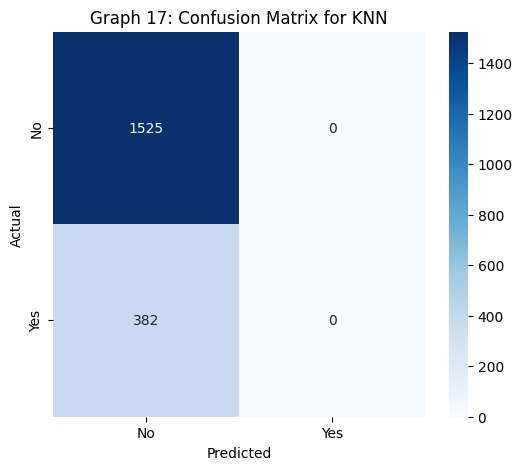

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Graph 17: Confusion Matrix for KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.2 Classification Report

Precision, recall, and F1-score are examined for both classes to provide a more detailed evaluation of the KNN model.

In [19]:
from sklearn.metrics import classification_report

print("KNN Classification Report (K=18)")
print(classification_report(y_test, y_pred))

KNN Classification Report (K=18)
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1525
         Yes       0.00      0.00      0.00       382

    accuracy                           0.80      1907
   macro avg       0.40      0.50      0.44      1907
weighted avg       0.64      0.80      0.71      1907



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
